### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import gseapy as gp
import hashlib
import os
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

### Load the bMINTY SQLite file provided as an example (test_data) in github repository 

*To run the notebook you will need both the pbmc.sha256 file and the pbmc.zip from folder test_data/pbmc*

In [2]:
def get_sha256(file_path, chunk_size=65536):
    sha256 = hashlib.sha256()
    try:
        with open(file_path, "rb") as f:
            while chunk := f.read(chunk_size):
                sha256.update(chunk)
        return sha256.hexdigest()
    except FileNotFoundError:
        return None

In [3]:
file_path = "/pbmc.sqlite3"
checksum_path = "/pbmc.sha256"

if os.path.exists(checksum_path):
    with open(checksum_path, "r") as f:
        expected_checksum = f.read().strip().split()[0]
    
    actual_checksum = get_sha256(file_path)
    
    if actual_checksum == expected_checksum:
        print("Checksum verification passed.")

        conn = sqlite3.connect(file_path)

        df_signal = pd.read_sql_query("""
            SELECT s.signal, i.name AS interval_name, c.name AS cell_name
            FROM signal s
            JOIN interval i ON s.interval_id = i.id
            JOIN cell c ON s.cell_id = c.id
        """, conn)

        df_cells = pd.read_sql_query("""
            SELECT name AS cell_name, label AS cell_label
            FROM cell
        """, conn)

        df_genes = pd.read_sql_query("""
            SELECT name AS interval_name, biotype AS biotype_label
            FROM interval
        """, conn)

        conn.close()
        print("df_signal shape:", df_signal.shape)
        print("df_cells shape:", df_cells.shape)
        print("df_genes shape:", df_genes.shape)
    else:
        print("Checksum verification failed.")
else:
    print(f"Checksum file {checksum_path} not found.")

Checksum verification passed.
df_signal shape: (2702861, 3)
df_cells shape: (3774, 2)
df_genes shape: (16791, 2)


In [4]:
df_genes=df_genes.set_index("interval_name")
df_genes

,biotype_label
interval_name,
AL627309.1,protein_coding
RP5-857K21.4,lincRNA
RP11-206L10.2,lincRNA
RP11-206L10.9,lincRNA
LINC00115,lincRNA
...,...
AC011841.1,protein_coding
AL354822.1,protein_coding
KIR2DL2,protein_coding


In [5]:
df_cells= df_cells.set_index("cell_name")
df_cells

,cell_label
cell_name,
CGTGATGATTTCAC_1_b_cells,b_cells
TTTGACTGTTGAGC_1_cd34_filtered,cd34_filtered
GACAGTACCTGTGA_1_memory_t,memory_t
CAGACCCTATTCCT_1_b_cells,b_cells
CAGCTAGATGACTG_1_cd4_t_helper,cd4_t_helper
...,...
ATGGTGACTGTCCC_1_cd34_filtered,cd34_filtered
GCCCAGGAACACTG_1_b_cells,b_cells
ATATGAACATGACC_1_cd4_t_helper,cd4_t_helper


In [6]:
expression_matrix = df_signal.pivot_table(
    index="cell_name",
    columns="interval_name",
    values="signal"
)
expression_matrix.columns.name = None
expression_matrix.index.name = None
expression_matrix = expression_matrix.fillna(0)
print(expression_matrix)

                                 7SK  A1BG  A1BG-AS1  A2M-AS1  AAAS  AACS  \
AAACATACCCAATG_1_cd56_nk         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATACGAATAG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATACGTTCAG_1_cd14_monocytes  0.0   0.0       0.0      0.0   0.0   0.0   
AAACATTGCTGATG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATTGGTACGT_1_cd34_filtered   0.0   0.0       0.0      0.0   0.0   0.0   
...                              ...   ...       ...      ...   ...   ...   
TTTGACTGCCTAAG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
TTTGACTGCTTGTT_1_b_cells         0.0   1.0       0.0      0.0   0.0   0.0   
TTTGACTGTCAGAC_1_cd34_filtered   0.0   1.0       1.0      0.0   1.0   0.0   
TTTGACTGTTGAGC_1_cd34_filtered   0.0   2.0       0.0      0.0   0.0   0.0   
TTTGACTGTTGTGG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   

                                 AADAT  AAED1  AAGAB  AAK1  ...  ZXDA  ZXDB

In [7]:
adata = sc.AnnData(X=expression_matrix)
adata.obs["cell_type"] = df_cells['cell_label']

### Initial Analysis QC until PCA

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

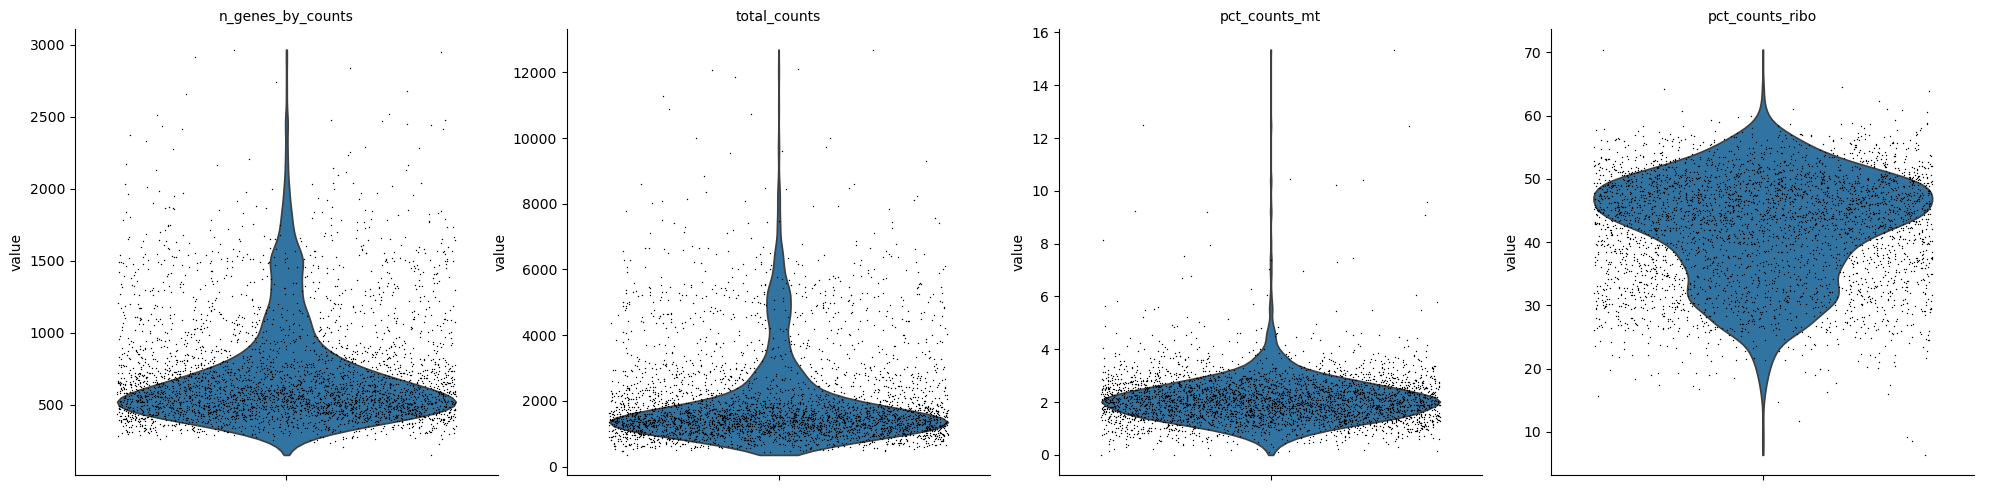

In [9]:
# mitochondrial genes & ribosomal genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt","pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

In [10]:
adata = adata[
    (adata.obs.n_genes_by_counts < 2000) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5),
    :,
].copy()

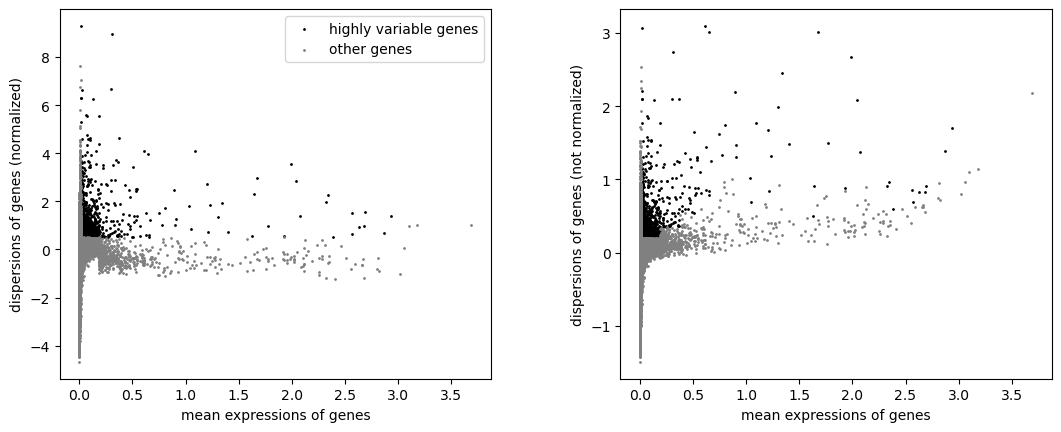

In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

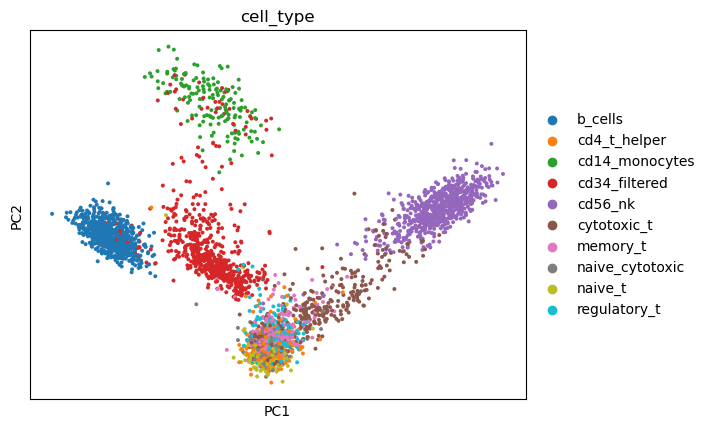

In [12]:
sc.tl.pca(adata)
sc.pl.pca(adata, color="cell_type")

### Differential gene expression analysis based on cell type information

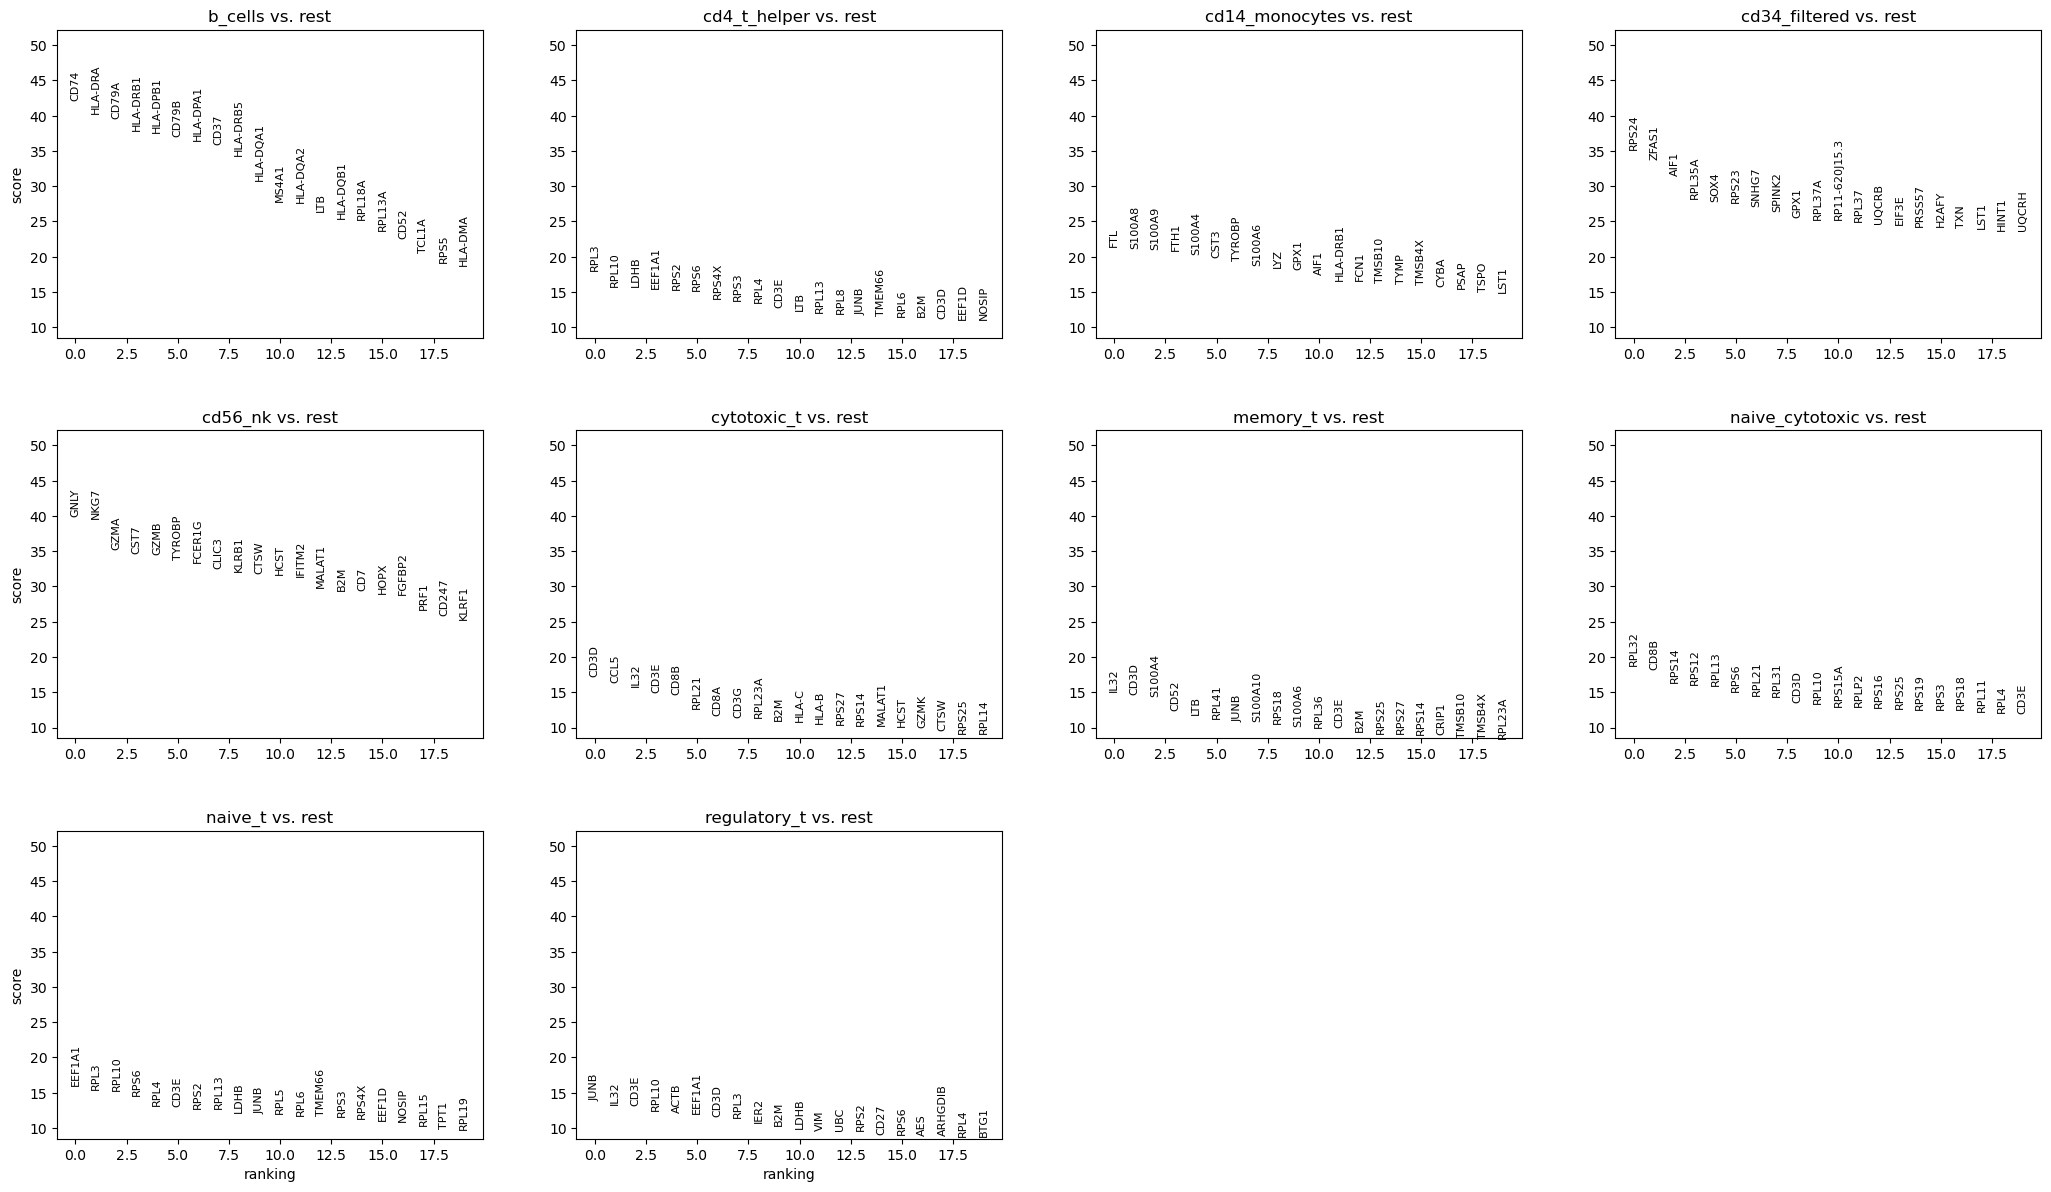

In [13]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata)

In [14]:
degs=sc.get.rank_genes_groups_df(adata,group=None, pval_cutoff = 0.01)
degs

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,b_cells,CD74,42.069515,4.475753,0.000000e+00,0.000000e+00
1,b_cells,HLA-DRA,40.280479,4.568464,0.000000e+00,0.000000e+00
2,b_cells,CD79A,39.598873,6.516940,0.000000e+00,0.000000e+00
3,b_cells,HLA-DRB1,37.813484,3.930968,0.000000e+00,0.000000e+00
4,b_cells,HLA-DPB1,37.526237,3.777007,3.439635e-308,9.676382e-305
...,...,...,...,...,...,...
5671,regulatory_t,RPL31,-13.281285,-0.728626,2.972488e-40,6.631468e-37
5672,regulatory_t,RPL37,-13.464501,-1.239405,2.530201e-41,7.117961e-38
5673,regulatory_t,RPL37A,-13.551299,-1.154468,7.784045e-42,2.737259e-38
5674,regulatory_t,RPS24,-13.607645,-1.352913,3.606816e-42,1.691116e-38


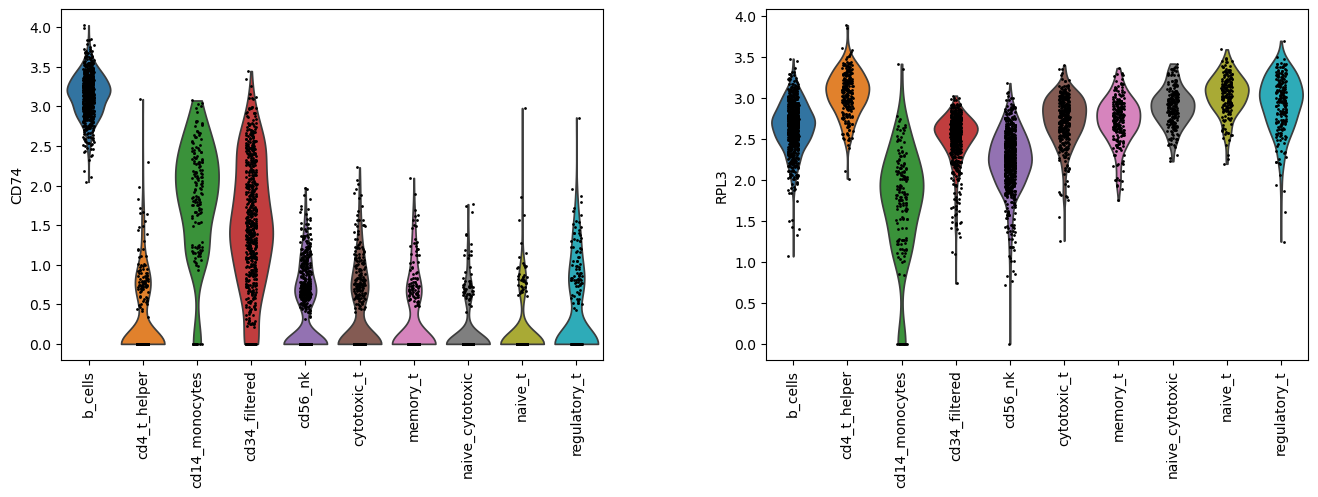

In [15]:
sc.pl.violin(adata, ["CD74", "RPL3"], groupby="cell_type",rotation=90,size=2)

In [16]:
degs_biotypes = degs.merge(
    df_genes[['biotype_label']],
    left_on='names',
    right_index=True,
    how='left'
)
degs_biotypes 

,group,names,scores,logfoldchanges,pvals,pvals_adj,biotype_label
0,b_cells,CD74,42.069515,4.475753,0.000000e+00,0.000000e+00,protein_coding
1,b_cells,HLA-DRA,40.280479,4.568464,0.000000e+00,0.000000e+00,protein_coding
2,b_cells,CD79A,39.598873,6.516940,0.000000e+00,0.000000e+00,protein_coding
3,b_cells,HLA-DRB1,37.813484,3.930968,0.000000e+00,0.000000e+00,protein_coding
4,b_cells,HLA-DPB1,37.526237,3.777007,3.439635e-308,9.676382e-305,protein_coding
...,...,...,...,...,...,...,...
5671,regulatory_t,RPL31,-13.281285,-0.728626,2.972488e-40,6.631468e-37,protein_coding
5672,regulatory_t,RPL37,-13.464501,-1.239405,2.530201e-41,7.117961e-38,protein_coding
5673,regulatory_t,RPL37A,-13.551299,-1.154468,7.784045e-42,2.737259e-38,protein_coding
5674,regulatory_t,RPS24,-13.607645,-1.352913,3.606816e-42,1.691116e-38,protein_coding


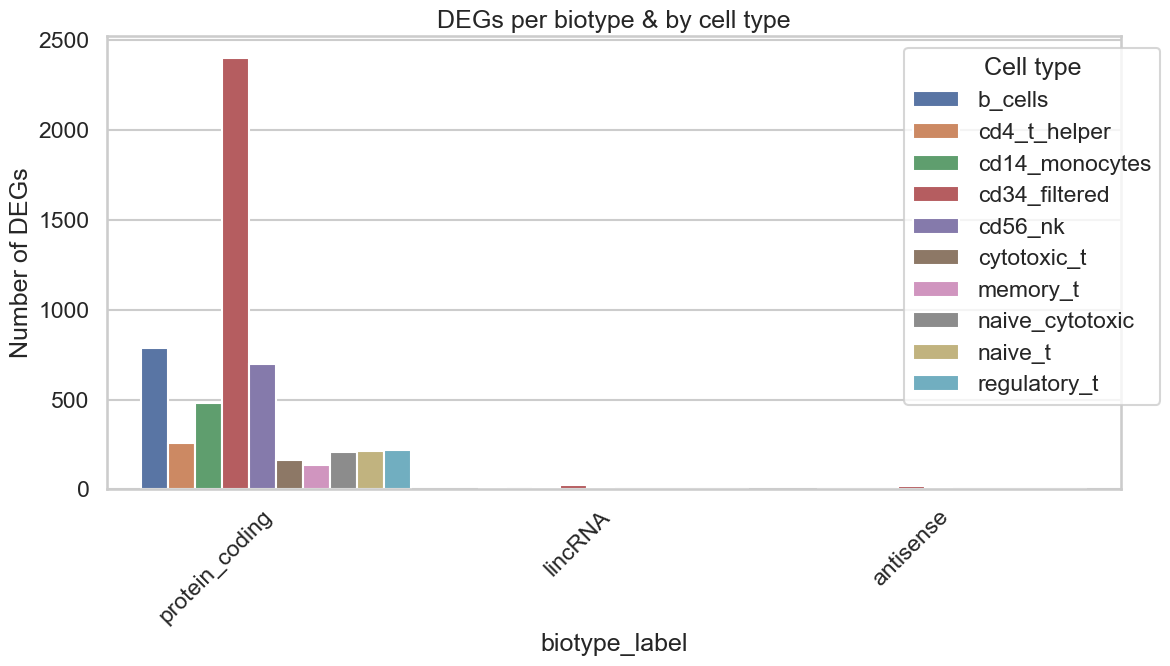

In [17]:
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12,7))
sns.countplot(
    data=degs_biotypes,
    x='biotype_label',
    hue='group'  
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of DEGs')
plt.title('DEGs per biotype & by cell type')
plt.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc='upper right')
plt.tight_layout()
plt.show()

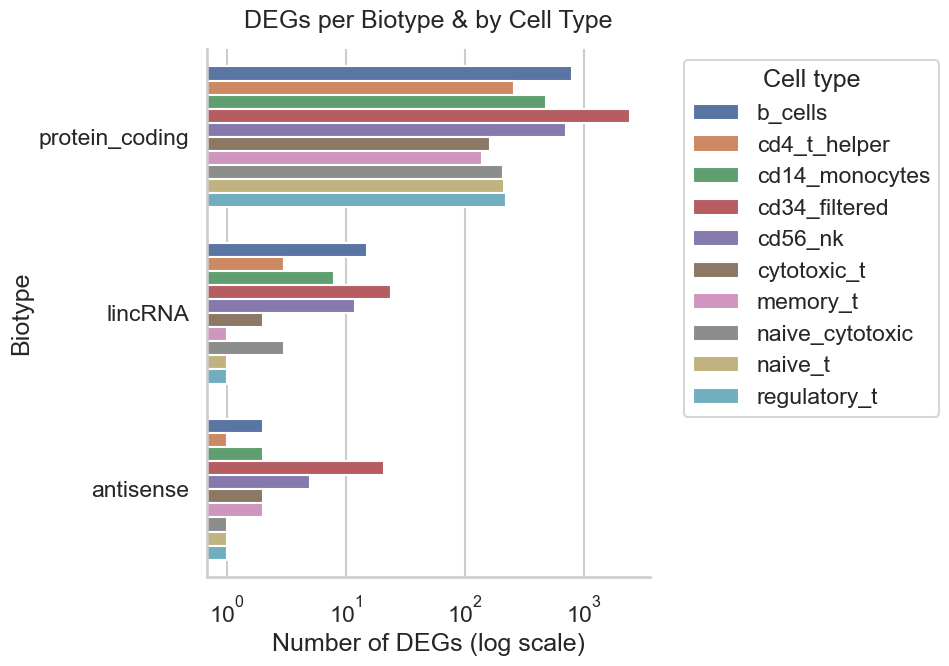

In [18]:
plt.figure(figsize=(10, 7))

ax = sns.countplot(
    data=degs_biotypes,
    y='biotype_label',
    hue='group',
    order=degs_biotypes['biotype_label'].value_counts().index
)

ax.set_xscale('log')

ax.set_xlabel("Number of DEGs (log scale)")
ax.set_ylabel("Biotype")
ax.set_title("DEGs per Biotype & by Cell Type", pad=15)

plt.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

### Enrichment Analysis using the degs

In [19]:
gene_sets = ['GO_Biological_Process_2025', 'KEGG_2021_Human','MSigDB_Hallmark_2020','Reactome_Pathways_2024']

In [20]:
results = {}
for type in degs['group'].unique():
    type_genes = degs[degs['group'] == type]['names'].tolist()
    enr = gp.enrichr(gene_list=type_genes,
                     gene_sets=gene_sets,
                     organism='human',
                     outdir=None)
    
    results[type] = enr
    print(f"Finished enrichment for type {type}")

Finished enrichment for type b_cells
Finished enrichment for type cd4_t_helper
Finished enrichment for type cd14_monocytes
Finished enrichment for type cd34_filtered
Finished enrichment for type cd56_nk
Finished enrichment for type cytotoxic_t
Finished enrichment for type memory_t
Finished enrichment for type naive_cytotoxic
Finished enrichment for type naive_t
Finished enrichment for type regulatory_t


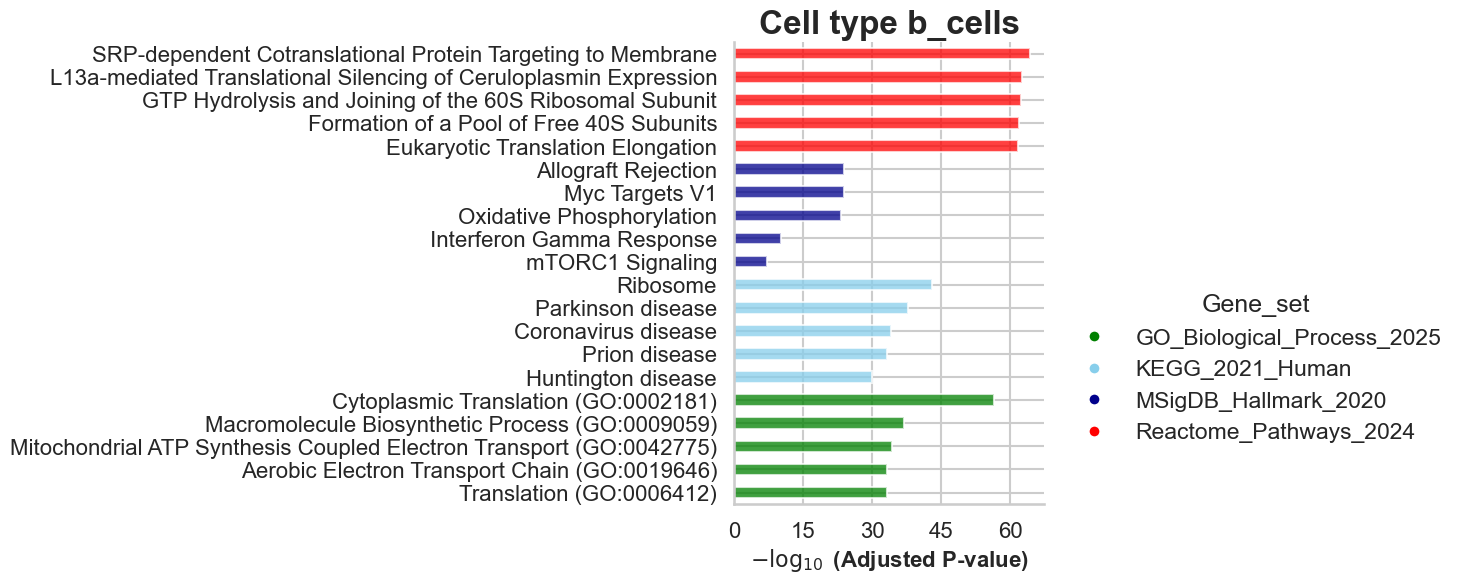

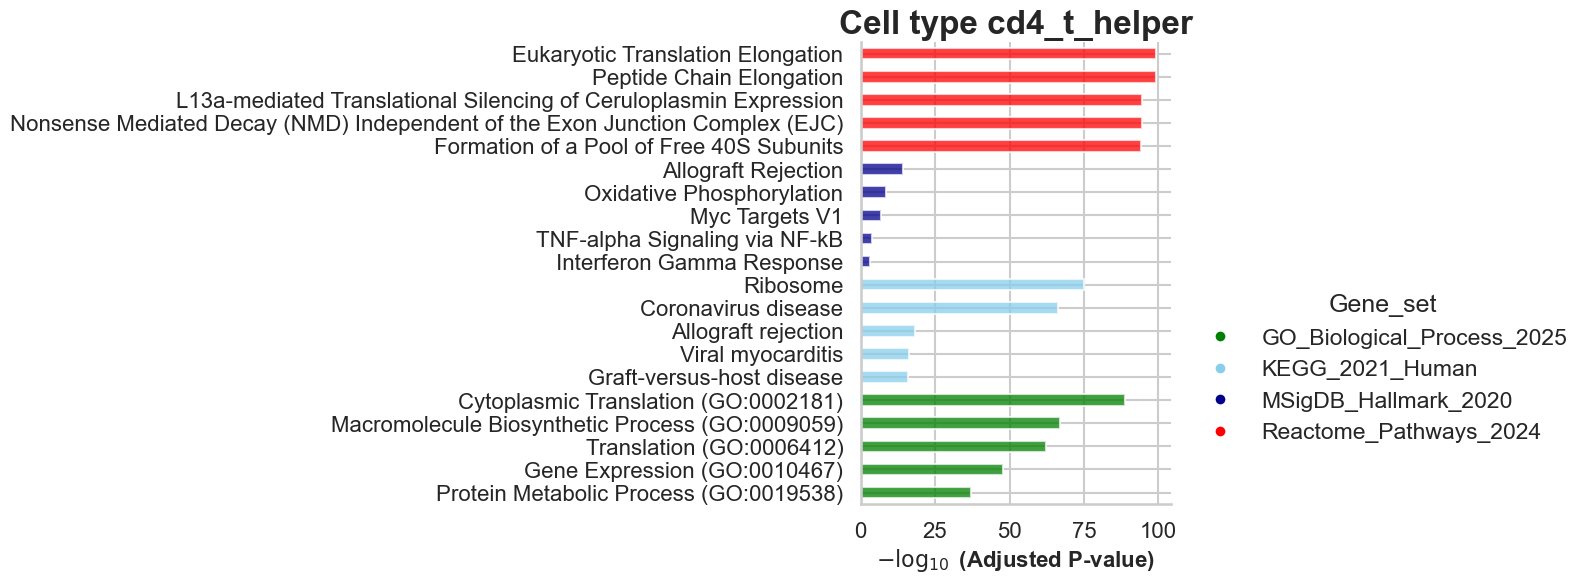

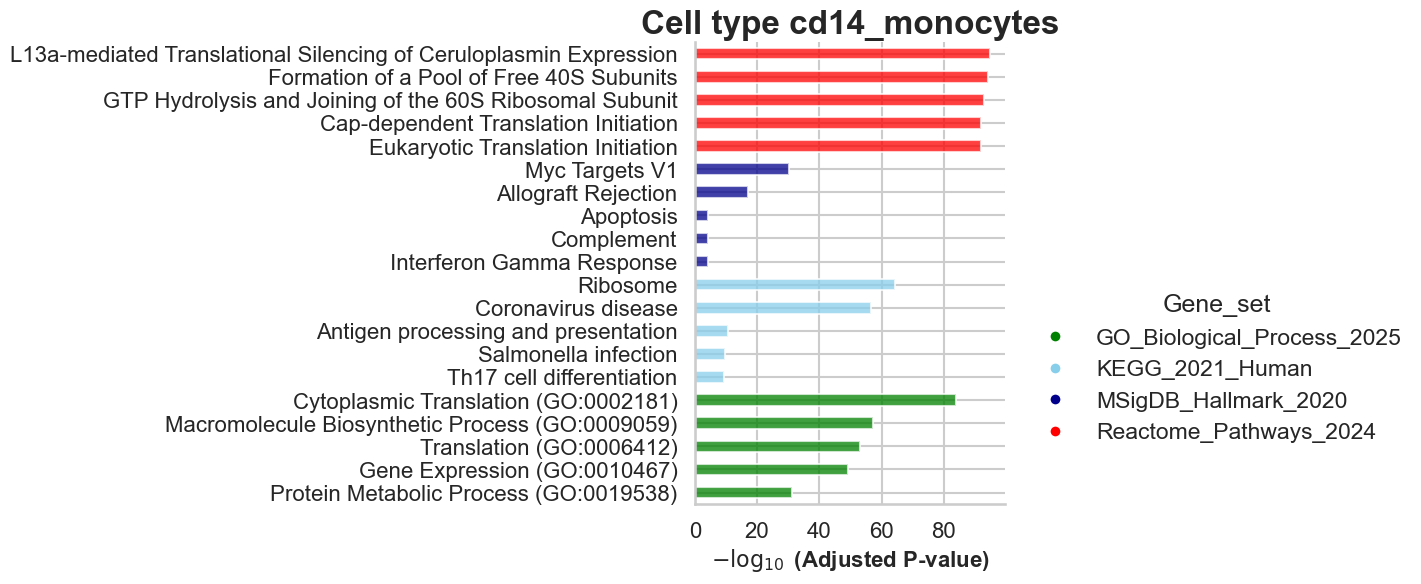

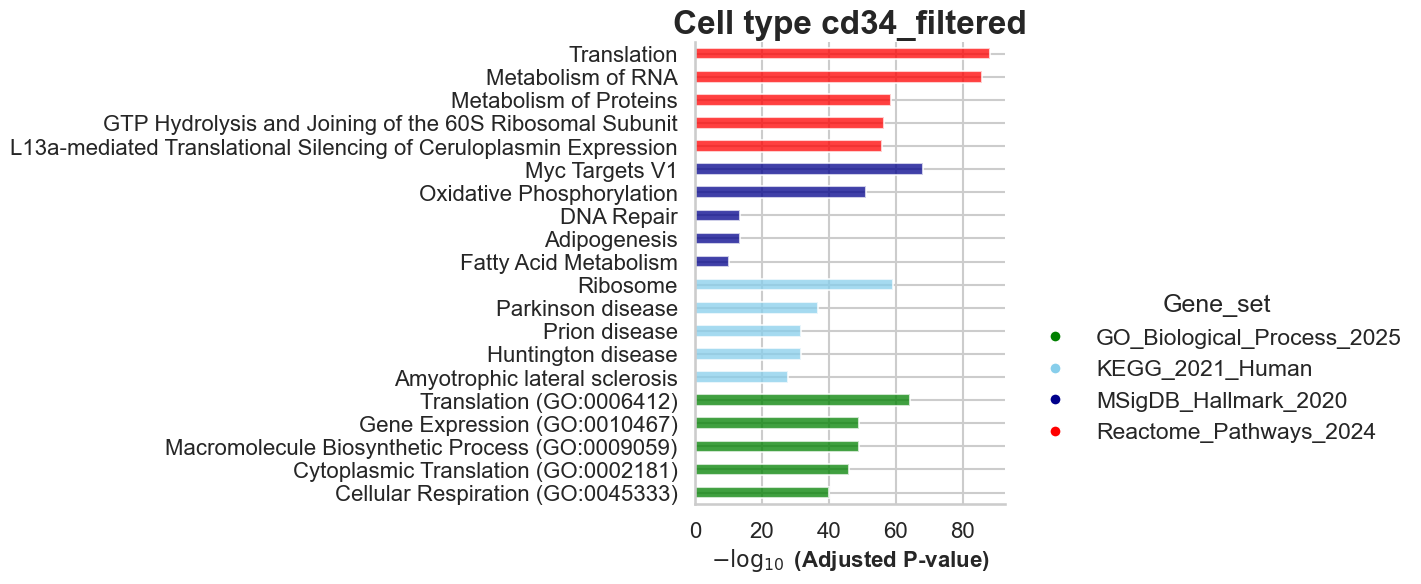

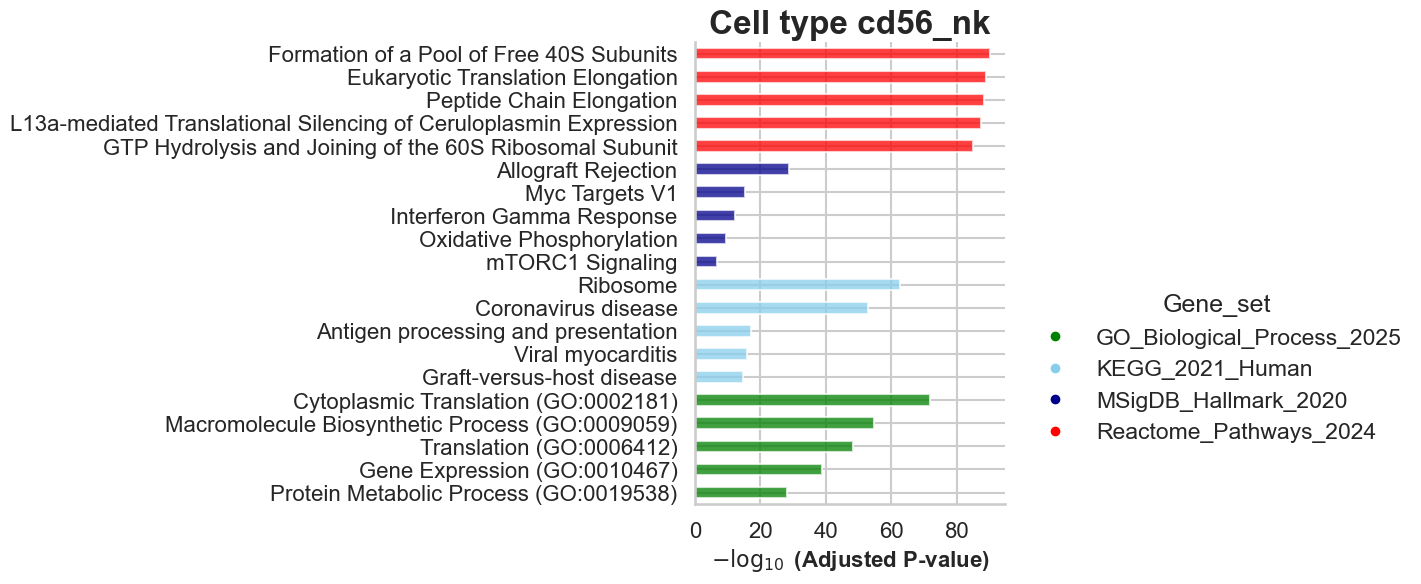

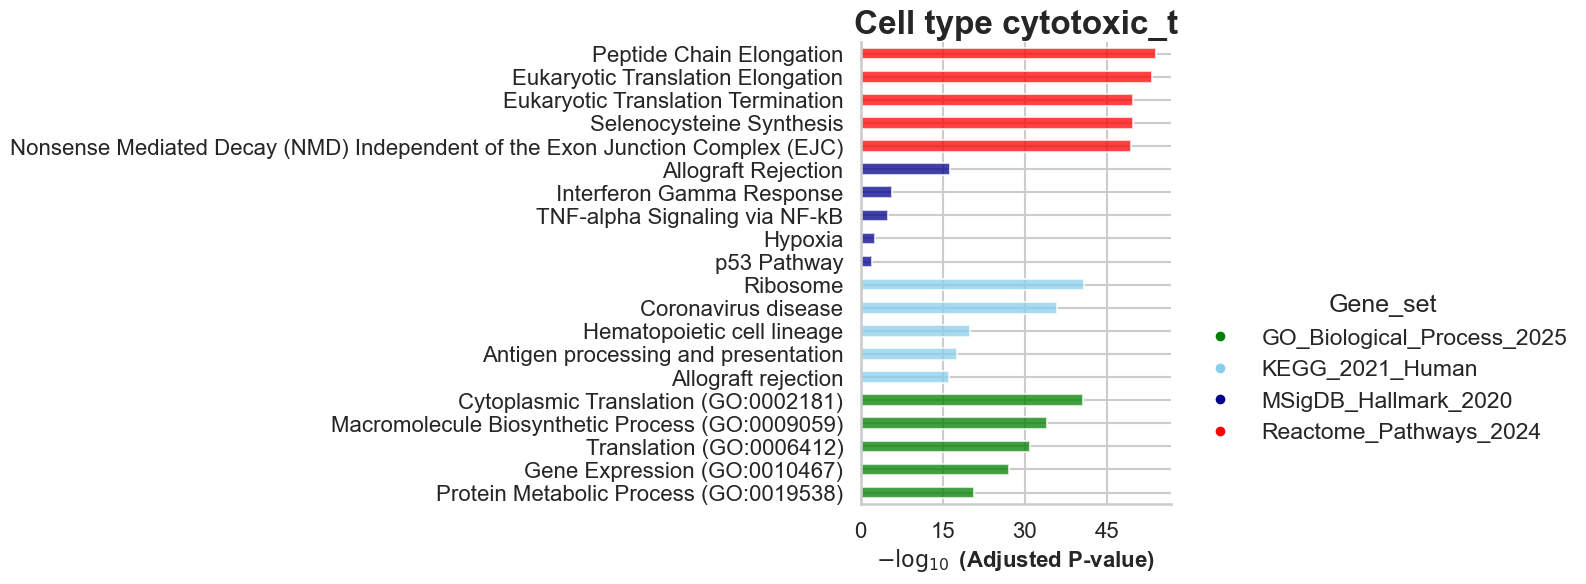

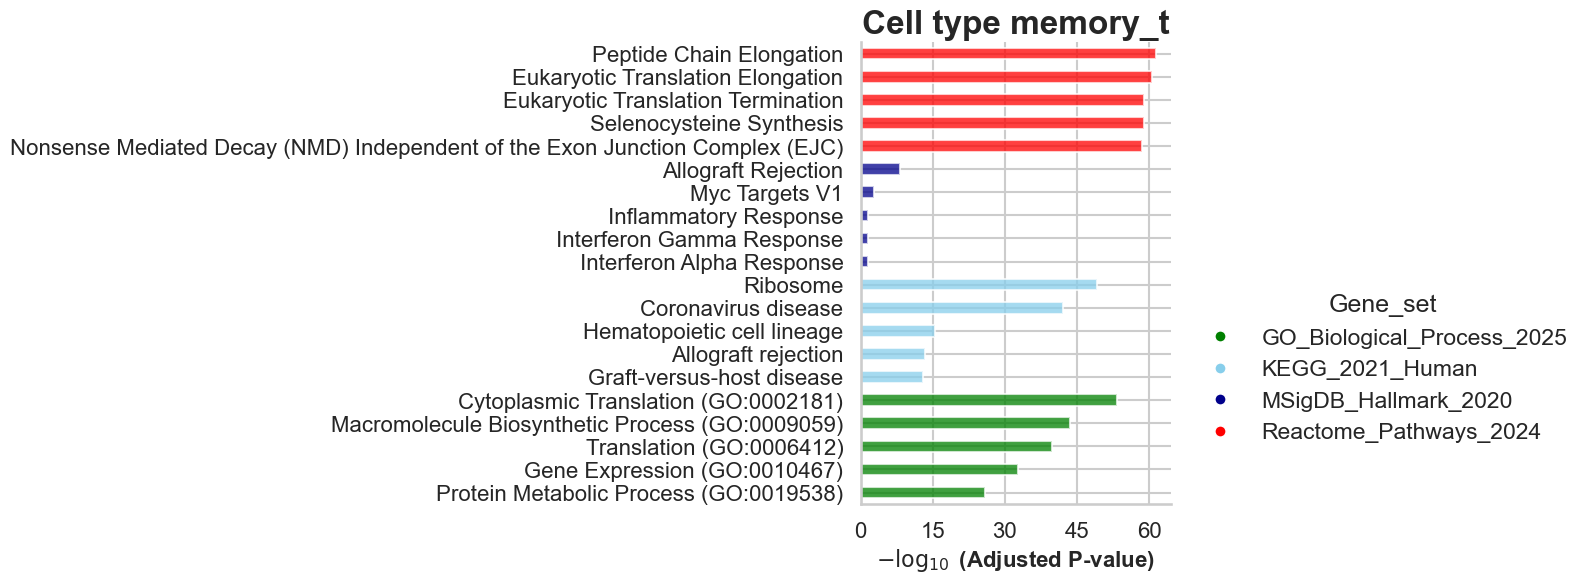

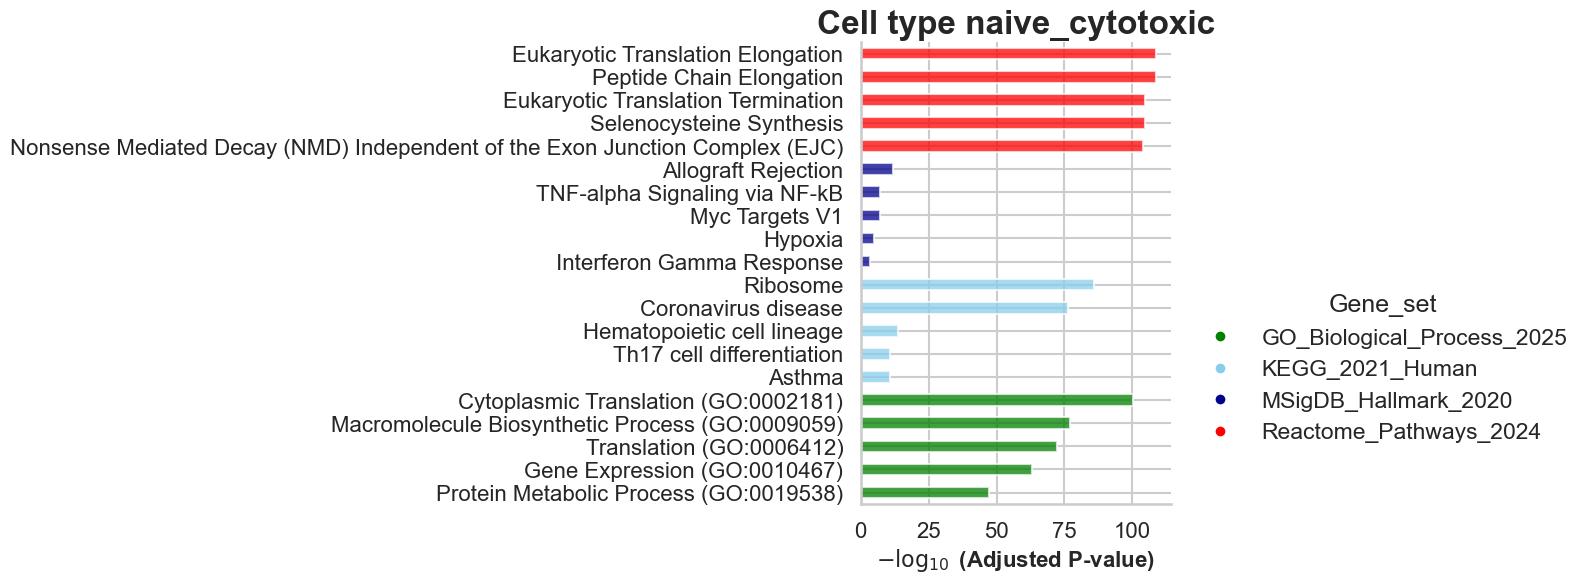

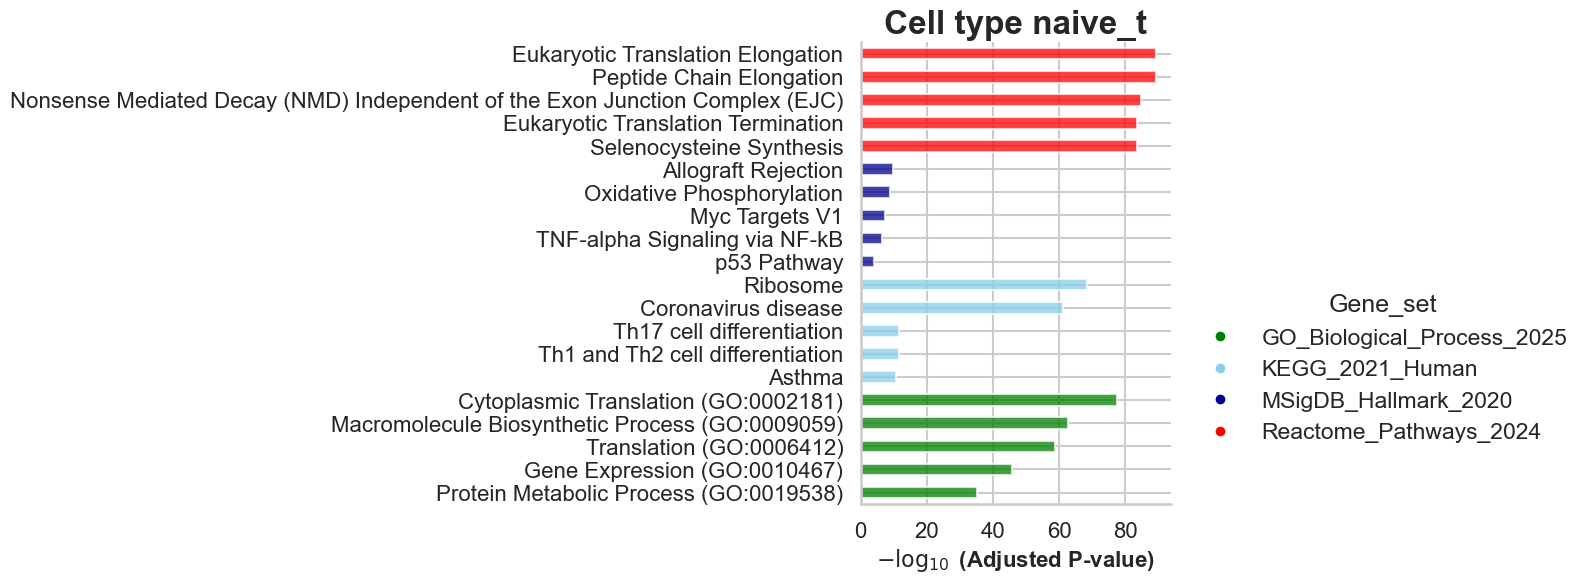

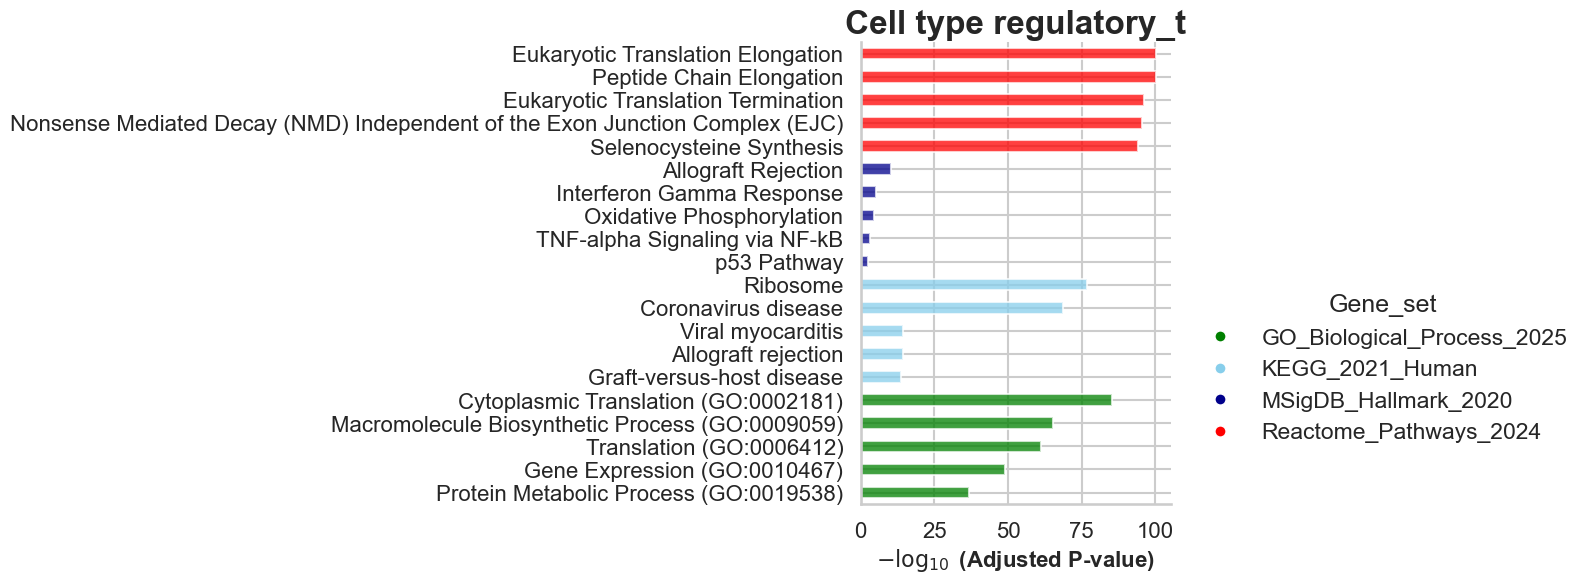

In [21]:
for type, enr_obj in results.items():
    res_df = enr_obj.results
    gp.barplot(res_df, 
            column="Adjusted P-value", 
            title=f"Cell type {type}",
            group='Gene_set',
            top_term=5,
            size=10,
            cutoff=0.05,
            color = {'KEGG_2021_Human': 'skyblue', 'GO_Biological_Process_2025':'green','MSigDB_Hallmark_2020':'darkblue','Reactome_Pathways_2024':'red'})
    plt.show()